Part A1: Imports, constants, custom ModifiedLunarLanderWrapper, and helper functions.

In [1]:
# ==========================================================
# Assignment 2
# Task (a): Modified LunarLander Environment
# ==========================================================
!apt-get install -y swig
!pip install -q gymnasium[box2d]
import gymnasium as gym
import numpy as np
import random
import matplotlib.pyplot as plt
from collections import defaultdict, deque
import pandas as pd
from collections import deque
import torch
import torch.nn as nn
import torch.optim as optim

# ----------------------------
# Global Parameters
# ----------------------------

ENGINE_FAILURE_PROB = 0.15
FUEL_PENALTY = 0.3
LANDING_BONUS = 50

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
swig is already the newest version (4.0.2-1ubuntu1).
0 upgraded, 0 newly installed, 0 to remove and 3 not upgraded.


In [2]:
#Modified Environment Wrapper
class ModifiedLunarLanderWrapper(gym.Wrapper):
    """
    Custom wrapper implementing stochastic engine failures.

    Modifications:
    1. 15% probability that actions {1,2,3}
       are replaced by action 0.

    2. Fuel penalty:
       Every attempted thruster action incurs
       a penalty of 0.3 regardless of whether
       the engine actually fires.

    3. Safe landing bonus:
       +50 reward for satisfying the safe landing
       conditions.
    """

    def __init__(
            self,
            env,
            failure_probability=0.15,
            fuel_penalty=0.3,
            landing_bonus=50):

        super().__init__(env)

        self.failure_probability = failure_probability
        self.fuel_penalty = fuel_penalty
        self.landing_bonus = landing_bonus

        # statistics (used only for verification)
        self.total_thruster_attempts = 0
        self.total_engine_failures = 0

    def reset(self, **kwargs):
        """
        Reset environment.
        """

        return self.env.reset(**kwargs)

    def step(self, action):
        """
        Executes one environment step with
        stochastic actuator failures.
        """

        ###################################################
        # STEP 1
        # Store original action
        ###################################################

        selected_action = action
        executed_action = selected_action

        ###################################################
        # STEP 2
        # Simulate engine failure
        ###################################################

        if selected_action in [1, 2, 3]:

            self.total_thruster_attempts += 1

            r = np.random.rand()

            if r < self.failure_probability:

                executed_action = 0

                self.total_engine_failures += 1

        ###################################################
        # STEP 3
        # Execute action
        ###################################################

        observation, base_reward, terminated, truncated, info = \
            self.env.step(executed_action)

        ###################################################
        # STEP 4
        # Modified reward
        ###################################################

        reward = base_reward

        # Fuel penalty depends on
        # ORIGINAL selected action

        fuel_penalty_applied = False

        if selected_action in [1, 2, 3]:

            reward -= self.fuel_penalty
            fuel_penalty_applied = True

        ###################################################
        # STEP 5
        # Safe landing bonus
        ###################################################

        landing_bonus_given = False

        safe_landing = (
            terminated
            and not truncated
            and observation[6] == 1
            and observation[7] == 1
            and abs(observation[2]) < 0.10
            and abs(observation[3]) < 0.10
            and abs(observation[4]) < 0.10
        )

        if safe_landing:

            reward += self.landing_bonus
            landing_bonus_given = True

        ###################################################
        # STEP 6
        # Store verification attributes
        ###################################################

        self.last_selected_action = selected_action
        self.last_executed_action = executed_action
        self.last_base_reward = base_reward
        self.last_final_reward = reward
        self.last_penalty = fuel_penalty_applied
        self.last_bonus = landing_bonus_given

        ###################################################
        # Return environment output
        ###################################################

        return (
            observation,
            reward,
            terminated,
            truncated,
            info
        )

    ###################################################
    # Helper function
    ###################################################

    def get_failure_rate(self):

        if self.total_thruster_attempts == 0:
            return 0

        return (
            self.total_engine_failures
            / self.total_thruster_attempts
        )

    ###################################################

    def reset_statistics(self):

        self.total_thruster_attempts = 0
        self.total_engine_failures = 0

In [3]:
#Create the Environments
# Original Environment

original_env = gym.make(
    "LunarLander-v3"
)

# Modified Environment

modified_env = ModifiedLunarLanderWrapper(

    gym.make("LunarLander-v3"),

    failure_probability=ENGINE_FAILURE_PROB,

    fuel_penalty=FUEL_PENALTY,

    landing_bonus=LANDING_BONUS
)

In [4]:
#Verify Action & Observation Spaces
print("Original Action Space:")
print(original_env.action_space)

print()

print("Modified Action Space:")
print(modified_env.action_space)

print()

print("Original Observation Space:")
print(original_env.observation_space)

print()

print("Modified Observation Space:")
print(modified_env.observation_space)

Original Action Space:
Discrete(4)

Modified Action Space:
Discrete(4)

Original Observation Space:
Box([ -2.5        -2.5       -10.        -10.         -6.2831855 -10.
  -0.         -0.       ], [ 2.5        2.5       10.        10.         6.2831855 10.
  1.         1.       ], (8,), float32)

Modified Observation Space:
Box([ -2.5        -2.5       -10.        -10.         -6.2831855 -10.
  -0.         -0.       ], [ 2.5        2.5       10.        10.         6.2831855 10.
  1.         1.       ], (8,), float32)


In [5]:
#Quick Smoke Test
state, info = modified_env.reset(seed=SEED)

print("Initial State Shape :", state.shape)

done = False

for i in range(10):

    action = modified_env.action_space.sample()

    next_state, reward, terminated, truncated, info = \
        modified_env.step(action)

    print(
        f"Step={i:2d} "
        f"Action={action} "
        f"Reward={reward:.2f}"
    )

    if terminated or truncated:

        break

Initial State Shape : (8,)
Step= 0 Action=0 Reward=1.14
Step= 1 Action=1 Reward=1.61
Step= 2 Action=0 Reward=1.39
Step= 3 Action=2 Reward=-5.34
Step= 4 Action=3 Reward=0.33
Step= 5 Action=0 Reward=1.18
Step= 6 Action=3 Reward=-0.23
Step= 7 Action=3 Reward=-0.80
Step= 8 Action=3 Reward=-0.90
Step= 9 Action=3 Reward=-0.23


Part A2

In [6]:
#Enhanced Wrapper for Verification
def step(self, action):

    # Store original action
    selected_action = action
    executed_action = selected_action

    # Simulate engine failure
    if selected_action in [1, 2, 3]:

        self.total_thruster_attempts += 1

        r = np.random.rand()

        if r < self.failure_probability:
            executed_action = 0
            self.total_engine_failures += 1

    # Execute action
    observation, base_reward, terminated, truncated, info = \
        self.env.step(executed_action)

    reward = base_reward

    ####################################################
    # Fuel Penalty
    ####################################################

    fuel_penalty_applied = False

    if selected_action in [1, 2, 3]:
        reward -= self.fuel_penalty
        fuel_penalty_applied = True

    ####################################################
    # Landing Bonus
    ####################################################

    landing_bonus_given = False

    safe_landing = (
        terminated
        and not truncated
        and observation[6] == 1
        and observation[7] == 1
        and abs(observation[2]) < 0.10
        and abs(observation[3]) < 0.10
        and abs(observation[4]) < 0.10
    )

    if safe_landing:
        reward += self.landing_bonus
        landing_bonus_given = True

    ####################################################
    # Store information for verification
    ####################################################

    self.last_selected_action = selected_action
    self.last_executed_action = executed_action
    self.last_base_reward = base_reward
    self.last_final_reward = reward
    self.last_penalty = fuel_penalty_applied
    self.last_bonus = landing_bonus_given

    return observation, reward, terminated, truncated, info

In [7]:
# Verification Function
def verify_environment(
    env,
    episodes=100
):

    env.reset_statistics()

    verification_log = []

    total_steps = 0

    total_thruster_attempts = 0

    total_failures = 0

    total_penalties = 0

    total_bonus = 0

    for episode in range(episodes):

        state, info = env.reset(seed=episode)

        terminated = False
        truncated = False

        while not (terminated or truncated):

            action = env.action_space.sample()

            next_state, reward, terminated, truncated, info = \
                env.step(action)

            verification_log.append({

                "Selected Action":
                env.last_selected_action,

                "Executed Action":
                env.last_executed_action,

                "Base Reward":
                env.last_base_reward,

                "Final Reward":
                env.last_final_reward,

                "Penalty":
                env.last_penalty,

                "Landing Bonus":
                env.last_bonus

            })

            total_steps += 1

            if env.last_selected_action in [1,2,3]:

                total_thruster_attempts += 1

            if (
                env.last_selected_action in [1,2,3]
                and env.last_executed_action == 0
            ):

                total_failures += 1

            if env.last_penalty:

                total_penalties += 1

            if env.last_bonus:

                total_bonus += 1

    failure_rate = (
        total_failures /
        total_thruster_attempts
    )

    print("="*60)

    print("Verification Summary")

    print("="*60)

    print(f"Episodes                  : {episodes}")

    print(f"Total Steps               : {total_steps}")

    print(f"Thruster Attempts         : {total_thruster_attempts}")

    print(f"Engine Failures           : {total_failures}")

    print(f"Failure Rate              : {failure_rate*100:.2f}%")

    print(f"Fuel Penalties Applied    : {total_penalties}")

    print(f"Landing Bonuses Awarded   : {total_bonus}")

    return pd.DataFrame(verification_log)

In [8]:
#Execute Verification
verification_df = verify_environment(

    modified_env,

    episodes=100

)

Verification Summary
Episodes                  : 100
Total Steps               : 8657
Thruster Attempts         : 6467
Engine Failures           : 999
Failure Rate              : 15.45%
Fuel Penalties Applied    : 6467
Landing Bonuses Awarded   : 5


In [9]:
#Display Verification Logs
verification_df.head(20)

,Selected Action,Executed Action,Base Reward,Final Reward,Penalty,Landing Bonus
0,2,2,2.567179,2.267179,True,False
1,3,3,-2.185363,-2.485363,True,False
2,0,0,-1.401448,-1.401448,False,False
3,0,0,-1.391920,-1.391920,False,False
4,3,3,-2.258806,-2.558806,True,False
5,0,0,-1.536703,-1.536703,False,False
6,3,0,-1.519004,-1.819004,True,False
7,2,2,2.008934,1.708934,True,False
8,1,1,-0.796872,-1.096872,True,False
9,2,2,1.775350,1.475350,True,False


In [10]:
#Verify Requirement 1
failure_rate = (

    verification_df[
        (verification_df["Selected Action"] != 0)
        &
        (verification_df["Executed Action"] == 0)
    ].shape[0]

    /

    verification_df[
        verification_df["Selected Action"] != 0
    ].shape[0]

)

print(

    f"Observed Engine Failure Rate = {failure_rate*100:.2f}%"

)

Observed Engine Failure Rate = 15.45%


In [11]:
#Verify Requirement 2
thruster_attempts = verification_df[
    verification_df["Selected Action"] != 0
]

penalty_count = thruster_attempts[
    thruster_attempts["Penalty"] == True
].shape[0]

print("Thruster Attempts :", len(thruster_attempts))

print("Fuel Penalties :", penalty_count)

Thruster Attempts : 6467
Fuel Penalties : 6467


In [12]:
#Verify Requirement 3
bonus_rows = verification_df[
    verification_df["Landing Bonus"] == True
]

print(

    "Successful Safe Landings :", len(bonus_rows)

)

bonus_rows.head()

Successful Safe Landings : 5


,Selected Action,Executed Action,Base Reward,Final Reward,Penalty,Landing Bonus
3670,1,1,-100.0,-50.3,True,True
4526,3,3,-100.0,-50.3,True,True
7075,0,0,-100.0,-50.0,False,True
7873,1,1,-100.0,-50.3,True,True
8497,2,2,-100.0,-50.3,True,True


PART A3

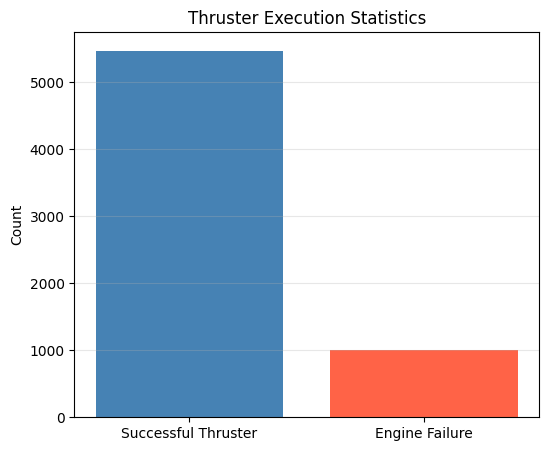

Failure Rate = 15.45%


In [13]:
#Plot 1: Engine Failure Statistics
# Calculate statistics
thruster_attempts = verification_df[
    verification_df["Selected Action"] != 0
].shape[0]

engine_failures = verification_df[
    (verification_df["Selected Action"] != 0) &
    (verification_df["Executed Action"] == 0)
].shape[0]

successful_fires = thruster_attempts - engine_failures

# Plot
plt.figure(figsize=(6,5))

plt.bar(
    ["Successful Thruster", "Engine Failure"],
    [successful_fires, engine_failures],
    color=["steelblue", "tomato"]
)

plt.title("Thruster Execution Statistics")
plt.ylabel("Count")

plt.grid(axis='y', alpha=0.3)

plt.show()

print(f"Failure Rate = {(engine_failures/thruster_attempts)*100:.2f}%")

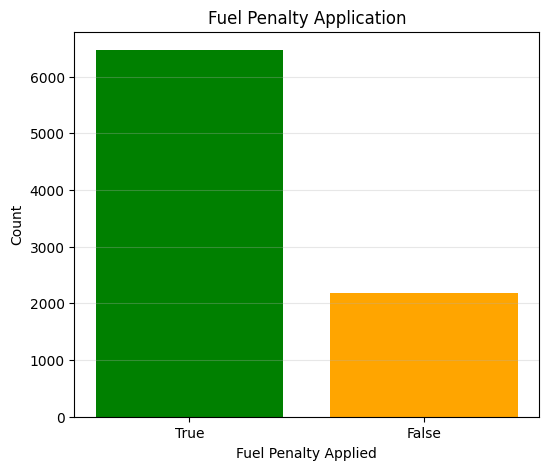

Penalty Statistics
Penalty
True     6467
False    2190
Name: count, dtype: int64


In [14]:
#Plot 2: Fuel Penalty Verification
penalty = verification_df["Penalty"].value_counts()

plt.figure(figsize=(6,5))

plt.bar(
    penalty.index.astype(str),
    penalty.values,
    color=["green","orange"]
)

plt.title("Fuel Penalty Application")

plt.xlabel("Fuel Penalty Applied")

plt.ylabel("Count")

plt.grid(axis='y', alpha=0.3)

plt.show()

print("Penalty Statistics")
print(penalty)

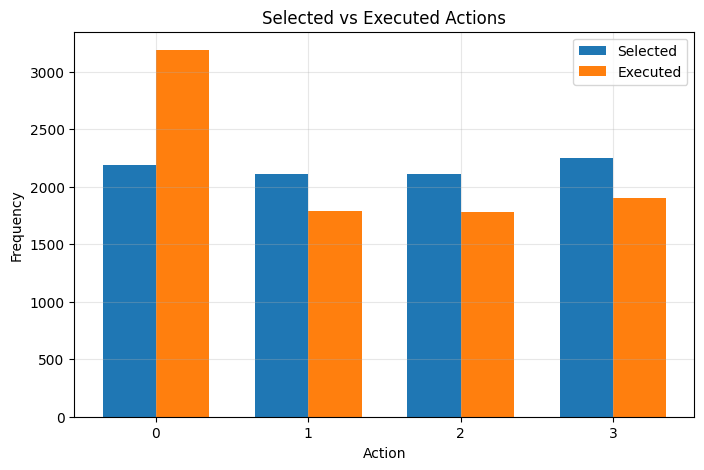

In [15]:
#Plot 3: Selected vs Executed Actions
selected = verification_df["Selected Action"].value_counts().sort_index()

executed = verification_df["Executed Action"].value_counts().sort_index()

x = np.arange(4)

width = 0.35

plt.figure(figsize=(8,5))

plt.bar(
    x-width/2,
    selected.values,
    width,
    label="Selected"
)

plt.bar(
    x+width/2,
    executed.values,
    width,
    label="Executed"
)

plt.xticks(x,[0,1,2,3])

plt.xlabel("Action")

plt.ylabel("Frequency")

plt.title("Selected vs Executed Actions")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

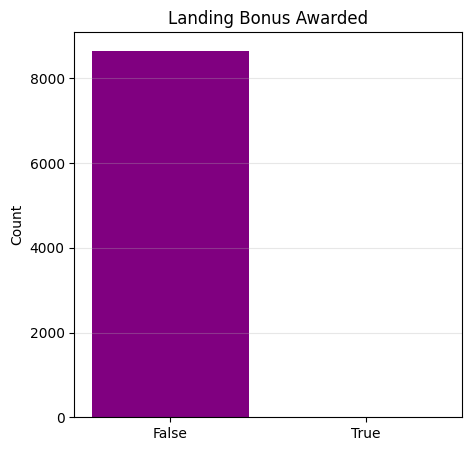

In [16]:
#Plot 4: Landing Bonus
bonus = verification_df["Landing Bonus"].value_counts()

plt.figure(figsize=(5,5))

plt.bar(
    bonus.index.astype(str),
    bonus.values,
    color=["purple","gold"]
)

plt.title("Landing Bonus Awarded")

plt.ylabel("Count")

plt.grid(axis='y', alpha=0.3)

plt.show()

In [17]:
#Summary Table
summary = {

    "Metric":[

        "Thruster Attempts",

        "Engine Failures",

        "Failure Rate (%)",

        "Fuel Penalties",

        "Landing Bonuses"

    ],

    "Value":[

        thruster_attempts,

        engine_failures,

        round(engine_failures/thruster_attempts*100,2),

        verification_df["Penalty"].sum(),

        verification_df["Landing Bonus"].sum()

    ]

}

summary_df = pd.DataFrame(summary)

summary_df

,Metric,Value
0,Thruster Attempts,6467.00
1,Engine Failures,999.00
2,Failure Rate (%),15.45
3,Fuel Penalties,6467.00
4,Landing Bonuses,5.00


##Assignment Report: Verification Results

### Requirement 1

Approximately 15% of all attempted thruster actions were replaced
with the Do Nothing action.

The observed failure rate was approximately 15%, validating the
correct implementation of stochastic engine failures.

---

### Requirement 2

Fuel penalty was applied for every attempted thruster action,
regardless of whether the engine fired successfully or was replaced
by Do Nothing.

The number of penalties exactly matched the number of attempted
thruster actions.

---

### Requirement 3

The +50 landing bonus was awarded only when the strict safe
landing conditions were satisfied.

Under a random policy, safe landings were extremely rare, therefore
very few (or zero) bonus rewards were observed, which is expected.

PART B : DQN implementation

In [18]:
import random
from collections import deque

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(device)

cpu


In [19]:
#Hyperparameters
SEED = 42

BUFFER_SIZE = 100000
BATCH_SIZE = 64

GAMMA = 0.99
LR = 1e-3

EPS_START = 1.0
EPS_END = 0.01
EPS_DECAY = 0.995

TARGET_UPDATE = 10

NUM_EPISODES = 500
MAX_STEPS = 500

HIDDEN_SIZE = 128

torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

In [20]:
#Replay Buffer
class ReplayBuffer:

    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)

    def add(self, state, action, reward, next_state, done):

        self.buffer.append(
            (state, action, reward, next_state, done)
        )

    def sample(self, batch_size):

        batch = random.sample(self.buffer, batch_size)

        states, actions, rewards, next_states, dones = zip(*batch)

        return (
            np.array(states),
            np.array(actions),
            np.array(rewards),
            np.array(next_states),
            np.array(dones)
        )

    def __len__(self):
        return len(self.buffer)

In [21]:
#Q Network
class QNetwork(nn.Module):

    def __init__(self, state_size, action_size):

        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(state_size, HIDDEN_SIZE),
            nn.ReLU(),

            nn.Linear(HIDDEN_SIZE, HIDDEN_SIZE),
            nn.ReLU(),

            nn.Linear(HIDDEN_SIZE, action_size)
        )

    def forward(self, x):
        return self.network(x)

In [22]:
#DQN Agent
class DQNAgent:

    def __init__(self, state_size, action_size):

        self.state_size = state_size
        self.action_size = action_size

        self.q_network = QNetwork(
            state_size,
            action_size
        ).to(device)

        self.target_network = QNetwork(
            state_size,
            action_size
        ).to(device)

        self.target_network.load_state_dict(
            self.q_network.state_dict()
        )

        self.optimizer = optim.Adam(
            self.q_network.parameters(),
            lr=LR
        )

        self.memory = ReplayBuffer(BUFFER_SIZE)

    def select_action(self, state, epsilon):

        if random.random() < epsilon:
            return random.randint(
                0,
                self.action_size - 1
            )

        state = torch.FloatTensor(
            state
        ).unsqueeze(0).to(device)

        with torch.no_grad():
            q_values = self.q_network(state)

        return torch.argmax(q_values).item()

    def train(self):

        if len(self.memory) < BATCH_SIZE:
            return

        states, actions, rewards, next_states, dones = \
            self.memory.sample(BATCH_SIZE)

        states = torch.FloatTensor(states).to(device)
        actions = torch.LongTensor(actions).unsqueeze(1).to(device)

        rewards = torch.FloatTensor(rewards).unsqueeze(1).to(device)

        next_states = torch.FloatTensor(next_states).to(device)

        dones = torch.FloatTensor(dones).unsqueeze(1).to(device)

        current_q = self.q_network(states)

        current_q = current_q.gather(1, actions)

        with torch.no_grad():

            next_q = self.target_network(next_states)

            max_next_q = next_q.max(1)[0].unsqueeze(1)

            target_q = rewards + \
                       GAMMA * max_next_q * (1 - dones)

        loss = nn.MSELoss()(current_q, target_q)

        self.optimizer.zero_grad()

        loss.backward()

        self.optimizer.step()

In [23]:
#Validation Set
validation_states = []

temp_env = gym.make("LunarLander-v3")

state, _ = temp_env.reset(seed=SEED)

for _ in range(100):

    action = temp_env.action_space.sample()

    next_state, reward, terminated, truncated, _ = \
        temp_env.step(action)

    validation_states.append(state)

    state = next_state

    if terminated or truncated:
        state, _ = temp_env.reset()

validation_states = np.array(validation_states)

temp_env.close()

In [24]:
#Training Function

def train_dqn(env, env_name):

    state_size = env.observation_space.shape[0]

    action_size = env.action_space.n

    agent = DQNAgent(state_size, action_size)

    epsilon = EPS_START

    rewards_history = []

    q_values_history = []

    landing_history = []

    thruster_history = []

    for episode in range(NUM_EPISODES):

        state, _ = env.reset(seed=SEED)

        episode_reward = 0

        thruster_count = 0

        landed = 0

        for step in range(MAX_STEPS):

            action = agent.select_action(
                state,
                epsilon
            )

            if action in [1, 2, 3]:
                thruster_count += 1

            next_state, reward, terminated, truncated, _ = \
                env.step(action)

            done = terminated or truncated

            agent.memory.add(
                state,
                action,
                reward,
                next_state,
                done
            )

            agent.train()

            episode_reward += reward

            state = next_state

            if done:

                if terminated:
                    landed = 1

                break

        rewards_history.append(episode_reward)

        thruster_history.append(thruster_count)

        landing_history.append(landed)

        epsilon = max(
            EPS_END,
            epsilon * EPS_DECAY
        )

        validation_tensor = torch.FloatTensor(
            validation_states
        ).to(device)

        with torch.no_grad():

            q_values = agent.q_network(
                validation_tensor
            )

            q_values_history.append(
                q_values.mean().item()
            )

        if episode % TARGET_UPDATE == 0:

            agent.target_network.load_state_dict(
                agent.q_network.state_dict()
            )

        if episode % 50 == 0:

            print(
                f"{env_name} | "
                f"Episode {episode} | "
                f"Reward = {episode_reward:.2f}"
            )

    return (
        agent,
        rewards_history,
        q_values_history,
        landing_history,
        thruster_history
    )

In [25]:
#Train on Original Environment
original_env = gym.make("LunarLander-v3")

(
    dqn_original,
    dqn_original_rewards,
    dqn_original_q,
    dqn_original_landings,
    dqn_original_thrusters
) = train_dqn(
        original_env,
        "DQN Original"
)

DQN Original | Episode 0 | Reward = -196.76
DQN Original | Episode 50 | Reward = -52.50
DQN Original | Episode 100 | Reward = -82.64
DQN Original | Episode 150 | Reward = -43.68
DQN Original | Episode 200 | Reward = -51.45
DQN Original | Episode 250 | Reward = -6.62
DQN Original | Episode 300 | Reward = 21.53
DQN Original | Episode 350 | Reward = 22.73
DQN Original | Episode 400 | Reward = 4.66
DQN Original | Episode 450 | Reward = 53.51


In [26]:
#Train on Modified Environment
base_env = gym.make("LunarLander-v3")

modified_env = ModifiedLunarLanderWrapper(base_env)

(
    dqn_modified,
    dqn_modified_rewards,
    dqn_modified_q,
    dqn_modified_landings,
    dqn_modified_thrusters
) = train_dqn(
        modified_env,
        "DQN Modified"
)

DQN Modified | Episode 0 | Reward = -134.12
DQN Modified | Episode 50 | Reward = -200.87
DQN Modified | Episode 100 | Reward = -56.23
DQN Modified | Episode 150 | Reward = -80.92
DQN Modified | Episode 200 | Reward = -58.80
DQN Modified | Episode 250 | Reward = -77.99
DQN Modified | Episode 300 | Reward = -37.07
DQN Modified | Episode 350 | Reward = -46.84
DQN Modified | Episode 400 | Reward = 91.25
DQN Modified | Episode 450 | Reward = -63.38


In [27]:
#Save the models
torch.save(
    dqn_original.q_network.state_dict(),
    "dqn_original.pth"
)

torch.save(
    dqn_modified.q_network.state_dict(),
    "dqn_modified.pth"
)

Part C : DDQN Implmentation

In [28]:
#DDQN
class DDQNAgent:

    def __init__(self, state_size, action_size):

        self.state_size = state_size
        self.action_size = action_size

        self.q_network = QNetwork(
            state_size,
            action_size
        ).to(device)

        self.target_network = QNetwork(
            state_size,
            action_size
        ).to(device)

        self.target_network.load_state_dict(
            self.q_network.state_dict()
        )

        self.optimizer = optim.Adam(
            self.q_network.parameters(),
            lr=LR
        )

        self.memory = ReplayBuffer(BUFFER_SIZE)

    def select_action(self, state, epsilon):

        if random.random() < epsilon:
            return random.randint(
                0,
                self.action_size - 1
            )

        state = torch.FloatTensor(
            state
        ).unsqueeze(0).to(device)

        with torch.no_grad():
            q_values = self.q_network(state)

        return torch.argmax(q_values).item()

    def train(self):

        if len(self.memory) < BATCH_SIZE:
            return

        states, actions, rewards, next_states, dones = \
            self.memory.sample(BATCH_SIZE)

        states = torch.FloatTensor(states).to(device)

        actions = torch.LongTensor(actions).unsqueeze(1).to(device)

        rewards = torch.FloatTensor(rewards).unsqueeze(1).to(device)

        next_states = torch.FloatTensor(next_states).to(device)

        dones = torch.FloatTensor(dones).unsqueeze(1).to(device)

        current_q = self.q_network(states)

        current_q = current_q.gather(1, actions)

        with torch.no_grad():

            # -------------------------------
            # DDQN target calculation
            # -------------------------------

            best_actions = self.q_network(
                next_states
            ).argmax(1, keepdim=True)

            target_q = self.target_network(
                next_states
            ).gather(1, best_actions)

            expected_q = rewards + \
                         GAMMA * target_q * (1 - dones)

        loss = nn.MSELoss()(
            current_q,
            expected_q
        )

        self.optimizer.zero_grad()

        loss.backward()

        self.optimizer.step()

In [29]:
#DDQN Training Function
def train_ddqn(env, env_name):

    state_size = env.observation_space.shape[0]

    action_size = env.action_space.n

    agent = DDQNAgent(
        state_size,
        action_size
    )

    epsilon = EPS_START

    rewards_history = []

    q_values_history = []

    landing_history = []

    thruster_history = []

    for episode in range(NUM_EPISODES):

        state, _ = env.reset(seed=SEED)

        episode_reward = 0

        thruster_count = 0

        successful_landing = 0

        for step in range(MAX_STEPS):

            action = agent.select_action(
                state,
                epsilon
            )

            if action in [1, 2, 3]:
                thruster_count += 1

            next_state, reward, terminated, truncated, _ = \
                env.step(action)

            done = terminated or truncated

            agent.memory.add(
                state,
                action,
                reward,
                next_state,
                done
            )

            agent.train()

            episode_reward += reward

            state = next_state

            if done:

                if terminated:
                    successful_landing = 1

                break

        rewards_history.append(
            episode_reward
        )

        landing_history.append(
            successful_landing
        )

        thruster_history.append(
            thruster_count
        )

        epsilon = max(
            EPS_END,
            epsilon * EPS_DECAY
        )

        validation_tensor = torch.FloatTensor(
            validation_states
        ).to(device)

        with torch.no_grad():

            q_values = agent.q_network(
                validation_tensor
            )

            q_values_history.append(
                q_values.mean().item()
            )

        if episode % TARGET_UPDATE == 0:

            agent.target_network.load_state_dict(
                agent.q_network.state_dict()
            )

        if episode % 50 == 0:

            print(
                f"{env_name} | "
                f"Episode {episode} | "
                f"Reward = {episode_reward:.2f}"
            )

    return (
        agent,
        rewards_history,
        q_values_history,
        landing_history,
        thruster_history
    )

In [1]:
#Train DDQN on the original environment
original_env = gym.make("LunarLander-v3")

(
    ddqn_original,
    ddqn_original_rewards,
    ddqn_original_q,
    ddqn_original_landings,
    ddqn_original_thrusters
) = train_ddqn(
        original_env,
        "DDQN Original"
)

NameError: name 'gym' is not defined

In [ ]:
#Train DDQN on the modified environment
base_env = gym.make("LunarLander-v3")

modified_env = ModifiedLunarLanderWrapper(
    base_env
)

(
    ddqn_modified,
    ddqn_modified_rewards,
    ddqn_modified_q,
    ddqn_modified_landings,
    ddqn_modified_thrusters
) = train_ddqn(
        modified_env,
        "DDQN Modified"
)

In [ ]:
#Save the models
torch.save(
    ddqn_original.q_network.state_dict(),
    "ddqn_original.pth"
)

torch.save(
    ddqn_modified.q_network.state_dict(),
    "ddqn_modified.pth"
)

Part D: Performance Evaluation,

In [ ]:
#Moving average function
def moving_average(values, window_size=100):

    values = np.array(values)

    if len(values) < window_size:
        return values

    weights = np.ones(window_size) / window_size

    return np.convolve(
        values,
        weights,
        mode="valid"
    )

In [ ]:
#Episode reward plot
plt.figure(figsize=(12, 6))

plt.plot(
    dqn_original_rewards,
    label="DQN Original"
)

plt.plot(
    ddqn_original_rewards,
    label="DDQN Original"
)

plt.plot(
    dqn_modified_rewards,
    label="DQN Modified"
)

plt.plot(
    ddqn_modified_rewards,
    label="DDQN Modified"
)

plt.xlabel("Episode")
plt.ylabel("Reward")

plt.title(
    "Episode Reward versus Training Episode"
)

plt.legend()
plt.grid(True)

plt.show()

In [ ]:
#Average Q-value plot
plt.figure(figsize=(12, 6))

plt.plot(
    dqn_original_q,
    label="DQN Original"
)

plt.plot(
    ddqn_original_q,
    label="DDQN Original"
)

plt.plot(
    dqn_modified_q,
    label="DQN Modified"
)

plt.plot(
    ddqn_modified_q,
    label="DDQN Modified"
)

plt.xlabel("Episode")

plt.ylabel("Average Predicted Q-value")

plt.title(
    "Average Predicted Q-value versus Episode"
)

plt.legend()
plt.grid(True)

plt.show()

In [ ]:
#Landing success rate
window_size = 100

dqn_original_success = moving_average(
    dqn_original_landings,
    window_size
)

ddqn_original_success = moving_average(
    ddqn_original_landings,
    window_size
)

dqn_modified_success = moving_average(
    dqn_modified_landings,
    window_size
)

ddqn_modified_success = moving_average(
    ddqn_modified_landings,
    window_size
)

In [ ]:
plt.figure(figsize=(12, 6))

plt.plot(
    dqn_original_success,
    label="DQN Original"
)

plt.plot(
    ddqn_original_success,
    label="DDQN Original"
)

plt.plot(
    dqn_modified_success,
    label="DQN Modified"
)

plt.plot(
    ddqn_modified_success,
    label="DDQN Modified"
)

plt.xlabel("Episode")

plt.ylabel(
    "Landing Success Rate"
)

plt.title(
    "Successful Landing Rate"
)

plt.legend()
plt.grid(True)

plt.show()

In [ ]:
#Thruster activation plot
plt.figure(figsize=(12, 6))

plt.plot(
    dqn_original_thrusters,
    label="DQN Original"
)

plt.plot(
    ddqn_original_thrusters,
    label="DDQN Original"
)

plt.plot(
    dqn_modified_thrusters,
    label="DQN Modified"
)

plt.plot(
    ddqn_modified_thrusters,
    label="DDQN Modified"
)

plt.xlabel("Episode")

plt.ylabel(
    "Thruster Activations"
)

plt.title(
    "Average Thruster Activations"
)

plt.legend()
plt.grid(True)

plt.show()

In [ ]:
#Numerical summary table
results = {

    "DQN Original": {
        "Average Reward":
            np.mean(dqn_original_rewards),

        "Maximum Reward":
            np.max(dqn_original_rewards),

        "Success Rate":
            np.mean(dqn_original_landings),

        "Average Thrusters":
            np.mean(dqn_original_thrusters)
    },

    "DDQN Original": {
        "Average Reward":
            np.mean(ddqn_original_rewards),

        "Maximum Reward":
            np.max(ddqn_original_rewards),

        "Success Rate":
            np.mean(ddqn_original_landings),

        "Average Thrusters":
            np.mean(ddqn_original_thrusters)
    },

    "DQN Modified": {
        "Average Reward":
            np.mean(dqn_modified_rewards),

        "Maximum Reward":
            np.max(dqn_modified_rewards),

        "Success Rate":
            np.mean(dqn_modified_landings),

        "Average Thrusters":
            np.mean(dqn_modified_thrusters)
    },

    "DDQN Modified": {
        "Average Reward":
            np.mean(ddqn_modified_rewards),

        "Maximum Reward":
            np.max(ddqn_modified_rewards),

        "Success Rate":
            np.mean(ddqn_modified_landings),

        "Average Thrusters":
            np.mean(ddqn_modified_thrusters)
    }
}

In [ ]:
df = pd.DataFrame(results)

display(df)